# BetterFastSpeech 2: Because none of the other source codes were hackable :/
---
[Shivam Mehta](https://www.kth.se/profile/smehta)



In [1]:
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [2]:
import datetime as dt
from pathlib import Path

import IPython.display as ipd
import numpy as np
import soundfile as sf
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Hifigan imports
from fs2.hifigan.config import v1
from fs2.hifigan.denoiser import Denoiser
from fs2.hifigan.env import AttrDict
from fs2.hifigan.models import Generator as HiFiGAN
# FS2 imports
from fs2.models.fastspeech2 import FastSpeech2
from fs2.text import sequence_to_text, text_to_sequence
from fs2.utils.model import denormalize
from fs2.utils.utils import get_user_data_dir, intersperse

In [9]:
import torchaudio

In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
# This allows for real time code changes being reflected in the notebook, no need to restart the kernel

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Filepaths

In [5]:
# FS2_CHECKPOINT = "logs/train/fs2_lj_det/runs/2024-02-26_17-27-33/checkpoints/last.ckpt"
FS2_CHECKPOINT = "logs/train/LJSpeech/runs/2026-07-24_19-44-19/checkpoints/last.ckpt"
# HIFIGAN_CHECKPOINT = get_user_data_dir() / "hifigan_T2_v1"
HIFIGAN_CHECKPOINT = "hifigan_univ_v1"
OUTPUT_FOLDER = "synth_output"

## Load FS2

In [6]:
def load_model(checkpoint_path):
    model = FastSpeech2.load_from_checkpoint(checkpoint_path, map_location=device, weights_only=False)
    model.eval()
    return model
count_params = lambda x: f"{sum(p.numel() for p in x.parameters()):,}"


model = load_model(FS2_CHECKPOINT)
print(f"Model loaded! Parameter count: {count_params(model)}")

Model loaded! Parameter count: 56,721,794


## Load HiFi-GAN (Vocoder)

In [7]:
def load_vocoder(checkpoint_path):
    h = AttrDict(v1)
    hifigan = HiFiGAN(h).to(device)
    hifigan.load_state_dict(torch.load(checkpoint_path, map_location=device)['generator'])
    _ = hifigan.eval()
    hifigan.remove_weight_norm()
    return hifigan

vocoder = load_vocoder(HIFIGAN_CHECKPOINT)
denoiser = Denoiser(vocoder, mode='zeros')

/home/victor/miniconda3/envs/betterfs2/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


### Helper functions to synthesise

In [8]:
from fs2.utils.audio import mel_spectrogram
import torchaudio as ta
import torch


@torch.inference_mode()
def load_reference_mel(filepath):
    audio, sr = ta.load(filepath)

    assert sr == 22050

    mel, _ = mel_spectrogram(
        audio,
        n_fft=1024,
        num_mels=80,
        sampling_rate=22050,
        hop_size=256,
        win_size=1024,
        fmin=0,
        fmax=8000,
        center=False,
    )

    return mel.unsqueeze(0).to(device)

In [9]:
@torch.inference_mode()
def process_text(text: str):
    x = torch.tensor(intersperse(text_to_sequence(text, ['english_cleaners2']), 0),dtype=torch.long, device=device)[None]
    x_lengths = torch.tensor([x.shape[-1]],dtype=torch.long, device=device)
    x_phones = sequence_to_text(x.squeeze(0).tolist())
    return {
        'x_orig': text,
        'x': x,
        'x_lengths': x_lengths,
        'x_phones': x_phones
    }


@torch.inference_mode()
def synthesise(
    text,
    spks=None,
    style_ref=None,
    style_lengths=None,
):
    text_processed = process_text(text)

    start_t = dt.datetime.now()

    output = model.synthesise(
        text_processed["x"],
        text_processed["x_lengths"],
        spks=spks,
        length_scale=length_scale,
        p_factor=p_factor,
        e_factor=e_factor,
        style_ref=style_ref,
        #style_lengths=style_lengths,
    )

    output.update(
        {
            "start_t": start_t,
            **text_processed,
        }
    )

    return output

@torch.inference_mode()
def to_waveform(mel, vocoder):
    audio = vocoder(mel).clamp(-1, 1)
    audio = denoiser(audio.squeeze(0), strength=0.0125).cpu().squeeze()
    return audio.cpu().squeeze()
    
def save_to_folder(filename: str, output: dict, folder: str):
    folder = Path(folder)
    folder.mkdir(exist_ok=True, parents=True)
    np.save(folder / f'{filename}', output['y_pred'].cpu().numpy())
    sf.write(folder / f'{filename}.wav', output['waveform'], 22050, 'PCM_24')

## Setup text to synthesise

In [10]:
texts = [
    "Twilight Sparkle knew that solving magical problems required patience, careful observation, logical reasoning, a willingness to reconsider old assumptions, the courage to admit mistakes, and enough determination to continue searching for answers even when every previous attempt had failed, because the greatest discoveries often appeared only after hours of careful study and thoughtful experimentation."
]

audio_path = "/home/victor/Documents/datasets/LJSpeech-1.1/wavs" + "/LJ002-0321.wav"

### Hyperparameters

In [11]:
length_scale = 1.0
p_factor=1.0
e_factor=1.0

## Synthesis

  0%|          | 0/1 [00:00<?, ?it/s]

Parameter containing:
tensor(0., device='cuda:0', requires_grad=True)
*****************************************************
Input text - 0
-----------------------------------------------------
Twilight Sparkle knew that solving magical problems required patience, careful observation, logical reasoning, a willingness to reconsider old assumptions, the courage to admit mistakes, and enough determination to continue searching for answers even when every previous attempt had failed, because the greatest discoveries often appeared only after hours of careful study and thoughtful experimentation.
*****************************************************
Phonetised text - 0
-----------------------------------------------------
_t_w_ˈ_a_ɪ_l_a_ɪ_t_ _s_p_ˈ_ɑ_ː_ɹ_k_ə_l_ _n_ˈ_u_ː_ _ð_æ_t_ _s_ˈ_ɑ_ː_l_v_ɪ_ŋ_ _m_ˈ_æ_d_ʒ_ɪ_k_ə_l_ _p_ɹ_ˈ_ɑ_ː_b_l_ə_m_z_ _ɹ_ᵻ_k_w_ˈ_a_ɪ_ɚ_d_ _p_ˈ_e_ɪ_ʃ_ə_n_s_,_ _k_ˈ_ɛ_ɹ_f_ə_l_ _ɑ_ː_b_z_ɚ_v_ˈ_e_ɪ_ʃ_ə_n_,_ _l_ˈ_ɑ_ː_d_ʒ_ɪ_k_ə_l_ _ɹ_ˈ_i_ː_z_ə_n_ɪ_ŋ_,_ _ɐ_ _w_ˈ_ɪ_l_ɪ_ŋ_n_ə_s_ _t_ə

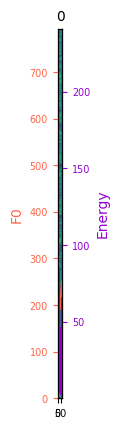

KeyError: 'y_pred'

: 

In [ ]:
outputs, rtfs = [], []
rtfs_w = []
reference_mel = load_reference_mel(audio_path)
for i, text in enumerate(tqdm(texts)):
    output = synthesise(text, style_ref=reference_mel) #, torch.tensor([15], device=device, dtype=torch.long).unsqueeze(0))
    output['waveform'] = to_waveform(output['mel'], vocoder)

    # Compute Real Time Factor (RTF) with HiFi-GAN
    t = (dt.datetime.now() - output['start_t']).total_seconds()
    rtf_w = t * 22050 / (output['waveform'].shape[-1])

    ## Pretty print
    print(f"{'*' * 53}")
    print(f"Input text - {i}")
    print(f"{'-' * 53}")
    print(output['x_orig'])
    print(f"{'*' * 53}")
    print(f"Phonetised text - {i}")
    print(f"{'-' * 53}")
    print(output['x_phones'])
    print(f"{'*' * 53}")
    print(f"RTF:\t\t{output['rtf']:.6f}")
    print(f"RTF Waveform:\t{rtf_w:.6f}")
    rtfs.append(output['rtf'])
    rtfs_w.append(rtf_w)

    ## Display the synthesised waveform
    model.plot_mel([(output['mel'].squeeze().T.cpu().numpy(), output['pitch_pred'].cpu().squeeze(), output['energy_pred'].cpu().squeeze())], [f"{i}"], show=True)
    plt.show()
    ipd.display(ipd.Audio(output['waveform'], rate=22050))

    ## Save the generated waveform
    save_to_folder(i, output, OUTPUT_FOLDER)

print(f"Mean RTF:\t\t\t\t{np.mean(rtfs):.6f} ± {np.std(rtfs):.6f}")
print(f"Mean RTF Waveform (incl. vocoder):\t{np.mean(rtfs_w):.6f} ± {np.std(rtfs_w):.6f}")

In [14]:
!pip install TorchCodec

  Using cached torchcodec-0.15.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (8.5 kB)
Using cached torchcodec-0.15.0-cp310-cp310-manylinux_2_28_x86_64.whl (3.0 MB)
